# BraTS 2021 Data Preprocessing

This notebook handles the preprocessing of BraTS 2021 dataset, supporting both .nii.gz and DICOM formats.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import pydicom
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from skimage import transform
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import torchio as tio
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
from model import SWINNVNet, CombinedLoss

## Config

In [3]:
# Dataset paths
NII_DATA_PATH = "/Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet"
DCM_DATA_PATH = "/Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet_dcm"

# Output path for preprocessed data
OUTPUT_PATH = "preprocessed_data"

# Create output directory
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Target dimensions for resampling
TARGET_SHAPE = (128, 128, 128)  # Reduced size for M1 Mac memory constraints

# MRI modalities to use
MODALITIES = ['flair', 't1', 't1ce', 't2']  # Standard BraTS modalities

# Sample percentage to use (for development/testing)
# Set to 1.0 for full dataset
SAMPLE_PERCENTAGE = 0.3  # Using 30% for faster development on M1 Mac

CONFIG = {
    'data_path': 'preprocessed_data',  # Path to preprocessed data
    'output_path': 'model_outputs',    # Path to save model checkpoints and results
    'batch_size': 2,                   # Small batch size for M1 Mac
    'num_epochs': 100,                 # Maximum number of epochs
    'learning_rate': 3e-4,             # Initial learning rate
    'weight_decay': 1e-5,              # L2 regularization
    'num_workers': 2,                  # Dataloader workers
    'patience': 10,                    # Early stopping patience
    'min_delta': 0.001,                # Minimum change to count as improvement
    'model_params': {
        'in_channels': 4,              # 4 MRI modalities (FLAIR, T1, T1ce, T2)
        'out_channels': 3,             # 3 segmentation classes (whole tumor, tumor core, enhancing tumor)
        'init_features': 16,           # Initial number of features (smaller for memory constraints)
        'transformer_blocks': 2        # Number of transformer blocks
    },
    'checkpoint_frequency': 5,         # Save checkpoint every N epochs
    'mixed_precision': False,           # Use mixed precision for faster training
}

In [16]:
 # Check for CUDA or MPS availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
#     print("Using MPS (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


## NIfTI (.nii.gz) Processing Functions

In [ ]:
def list_nii_files():
    """List all NIfTI files in the dataset by patient ID"""
    dataset_structure = {}
    
    # Get all folder paths
    for folder in os.listdir(NII_DATA_PATH):
        folder_path = os.path.join(NII_DATA_PATH, folder)
        if os.path.isdir(folder_path):
            patients = []
            for patient_dir in os.listdir(folder_path):
                patient_path = os.path.join(folder_path, patient_dir)
                if os.path.isdir(patient_path):
                    patients.append(patient_dir)
            dataset_structure[folder] = patients
    
    # Build patient to file mapping
    patient_files = {}
    for folder, patients in dataset_structure.items():
        for patient in patients:
            patient_path = os.path.join(NII_DATA_PATH, folder, patient)
            files = {}
            
            # Look for all modalities and seg files
            for modality in MODALITIES + ['seg']:
                # Handle different naming patterns
                patterns = [
                    f"*{modality}.nii.gz",  # Standard pattern
                    f"*{modality.upper()}.nii.gz",  # Uppercase
                    f"*{patient}_{modality}.nii.gz"  # Patient ID in filename
                ]
                
                for pattern in patterns:
                    matches = glob.glob(os.path.join(patient_path, pattern))
                    if matches:
                        files[modality] = matches[0]
                        break
            
            # Only add patient if all required files are found
            if all(modality in files for modality in MODALITIES + ['seg']):
                patient_files[f"{folder}_{patient}"] = files
    
    return patient_files

def load_nii_volume(file_path):
    """Load a NIfTI volume"""
    nii = nib.load(file_path)
    volume = nii.get_fdata()
    return volume

def resample_volume(volume, target_shape=TARGET_SHAPE):
    """Resample a volume to target dimensions"""
    # Simple resize using skimage
    return transform.resize(volume, target_shape, order=1, preserve_range=True)

def normalize_volume(volume, modality):
    """Normalize volume based on modality"""
    # Remove outliers by clipping to 99th percentile
    non_zero = volume[volume > 0]
    if len(non_zero) > 0:
        p99 = np.percentile(non_zero, 99)
        volume = np.clip(volume, 0, p99)
    
    # Z-score normalization within brain region
    mask = volume > 0
    if np.sum(mask) > 0:
        mean = np.mean(volume[mask])
        std = np.std(volume[mask])
        if std > 0:
            volume[mask] = (volume[mask] - mean) / std
    
    return volume

def process_patient_nii(patient_id, files):
    """Process all modalities for a single patient"""
    try:
        # Load and preprocess each modality
        modality_volumes = {}
        for modality in MODALITIES:
            volume = load_nii_volume(files[modality])
            volume = resample_volume(volume)
            volume = normalize_volume(volume, modality)
            modality_volumes[modality] = volume
        
        # Load and preprocess segmentation
        seg_volume = load_nii_volume(files['seg'])
        seg_volume = resample_volume(seg_volume)
        
        # Convert segmentation to one-hot encoding
        # BraTS labels: 0=background, 1=necrotic core, 2=edema, 4=enhancing tumor
        # Convert to: 0=background, 1=whole tumor (1+2+4), 2=tumor core (1+4), 3=enhancing tumor (4)
        seg_one_hot = np.zeros((*seg_volume.shape, 3), dtype=np.float32)
        whole_tumor = (seg_volume > 0).astype(np.float32)
        tumor_core = np.logical_or(seg_volume == 1, seg_volume == 4).astype(np.float32)
        enhancing = (seg_volume == 4).astype(np.float32)
        
        seg_one_hot[..., 0] = whole_tumor
        seg_one_hot[..., 1] = tumor_core
        seg_one_hot[..., 2] = enhancing
        
        # Stack all modalities into a single array
        input_volume = np.stack([modality_volumes[mod] for mod in MODALITIES], axis=0)
        
        # Save to H5 file
        output_file = os.path.join(OUTPUT_PATH, f"{patient_id}.h5")
        with h5py.File(output_file, 'w') as f:
            f.create_dataset('input', data=input_volume.astype(np.float32))
            f.create_dataset('seg', data=seg_one_hot.astype(np.float32))
        
        return patient_id, True
    except Exception as e:
        print(f"Error processing {patient_id}: {str(e)}")
        return patient_id, False

## DICOM Processing Functions

In [ ]:
def list_dcm_files():
    """List all DICOM files in the dataset by patient ID"""
    dataset_structure = {}
    
    # Get all folder paths
    for folder in os.listdir(DCM_DATA_PATH):
        folder_path = os.path.join(DCM_DATA_PATH, folder)
        if os.path.isdir(folder_path):
            patients = []
            for patient_dir in os.listdir(folder_path):
                patient_path = os.path.join(folder_path, patient_dir)
                if os.path.isdir(patient_path):
                    patients.append(patient_dir)
            dataset_structure[folder] = patients
    
    # Build patient to file mapping
    patient_files = {}
    for folder, patients in dataset_structure.items():
        for patient in patients:
            patient_path = os.path.join(DCM_DATA_PATH, folder, patient)
            modality_dirs = {}
            
            # Check for each modality directory
            for modality in MODALITIES + ['seg']:
                for dir_name in os.listdir(patient_path):
                    dir_path = os.path.join(patient_path, dir_name)
                    if os.path.isdir(dir_path):
                        # Check if directory name contains modality name
                        if modality.lower() in dir_name.lower():
                            modality_dirs[modality] = dir_path
                            break
            
            # Only add patient if all required modalities are found
            if all(modality in modality_dirs for modality in MODALITIES + ['seg']):
                patient_files[f"{folder}_{patient}"] = modality_dirs
    
    return patient_files

def load_dcm_series(directory):
    """Load a DICOM series from a directory"""
    # Get list of all DICOM files
    dcm_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.dcm')]
    
    # Read first file to get metadata
    first_slice = pydicom.dcmread(dcm_files[0])
    
    # Extract position information if possible
    slice_positions = []
    for file in dcm_files:
        ds = pydicom.dcmread(file, stop_before_pixels=True)
        if hasattr(ds, 'ImagePositionPatient'):
            # Use the z-coordinate for sorting
            slice_positions.append((file, float(ds.ImagePositionPatient[2])))
        else:
            # If position information is not available, use instance number
            instance = int(ds.InstanceNumber) if hasattr(ds, 'InstanceNumber') else 0
            slice_positions.append((file, instance))
    
    # Sort files by position
    slice_positions.sort(key=lambda x: x[1])
    sorted_files = [x[0] for x in slice_positions]
    
    # Read all slices
    slices = [pydicom.dcmread(file) for file in sorted_files]
    
    # Extract spacing information
    pixel_spacing = slices[0].PixelSpacing if hasattr(slices[0], 'PixelSpacing') else [1, 1]
    slice_thickness = slices[0].SliceThickness if hasattr(slices[0], 'SliceThickness') else 1
    
    # Create 3D volume
    img_shape = list(slices[0].pixel_array.shape)
    img_shape.append(len(slices))
    volume = np.zeros(img_shape)
    
    # Fill volume with slice data
    for i, s in enumerate(slices):
        volume[:, :, i] = s.pixel_array
    
    # Transpose to standard orientation
    volume = volume.transpose(2, 0, 1)
    
    return volume

def process_patient_dcm(patient_id, directories):
    """Process all modalities for a single patient using DICOM files"""
    try:
        # Load and preprocess each modality
        modality_volumes = {}
        for modality in MODALITIES:
            volume = load_dcm_series(directories[modality])
            volume = resample_volume(volume)
            volume = normalize_volume(volume, modality)
            modality_volumes[modality] = volume
        
        # Load and preprocess segmentation
        seg_volume = load_dcm_series(directories['seg'])
        seg_volume = resample_volume(seg_volume)
        
        # Convert segmentation to one-hot encoding (same as NIfTI function)
        seg_one_hot = np.zeros((*seg_volume.shape, 3), dtype=np.float32)
        whole_tumor = (seg_volume > 0).astype(np.float32)
        tumor_core = np.logical_or(seg_volume == 1, seg_volume == 4).astype(np.float32)
        enhancing = (seg_volume == 4).astype(np.float32)
        
        seg_one_hot[..., 0] = whole_tumor
        seg_one_hot[..., 1] = tumor_core
        seg_one_hot[..., 2] = enhancing
        
        # Stack all modalities into a single array
        input_volume = np.stack([modality_volumes[mod] for mod in MODALITIES], axis=0)
        
        # Save to H5 file
        output_file = os.path.join(OUTPUT_PATH, f"{patient_id}.h5")
        with h5py.File(output_file, 'w') as f:
            f.create_dataset('input', data=input_volume.astype(np.float32))
            f.create_dataset('seg', data=seg_one_hot.astype(np.float32))
        
        return patient_id, True
    except Exception as e:
        print(f"Error processing {patient_id}: {str(e)}")
        return patient_id, False

## Process the Data

In [ ]:
def process_dataset(use_nii=True):
    """Process the entire dataset, using either NIfTI or DICOM files"""
    # Get patient files
    patient_files = list_nii_files() if use_nii else list_dcm_files()
    print(f"Found {len(patient_files)} patients with all required files")
    
    # Take a sample if needed
    if SAMPLE_PERCENTAGE < 1.0:
        sample_size = int(len(patient_files) * SAMPLE_PERCENTAGE)
        patient_ids = list(patient_files.keys())
        np.random.shuffle(patient_ids)
        selected_patients = patient_ids[:sample_size]
        patient_files = {pid: patient_files[pid] for pid in selected_patients}
        print(f"Selected {len(patient_files)} patients for processing")
    
    # Process each patient
    results = []
    process_func = process_patient_nii if use_nii else process_patient_dcm
    
    # Process in parallel
    # Process in parallel
    with ThreadPoolExecutor(max_workers=4) as executor:  # Limit to 4 workers for M1 Mac
        futures = {executor.submit(process_func, patient_id, files): patient_id 
                for patient_id, files in patient_files.items()}
        
        # Track progress with tqdm
        results = []
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing patients"):
            patient_id = futures[future]
            try:
                result = future.result()
                results.append(result)
            except Exception as e:
                print(f"Error processing patient {patient_id}: {e}")
                results.append((patient_id, False))
    
    # Count successful processing
    successful = sum(1 for _, success in results if success)
    print(f"Successfully processed {successful} out of {len(patient_files)} patients")
    
    # Create dataset split
    create_dataset_split()

def create_dataset_split(train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """Create train/val/test splits"""
    # Get all preprocessed files
    files = glob.glob(os.path.join(OUTPUT_PATH, "*.h5"))
    np.random.shuffle(files)
    
    # Split into train/val/test
    train_end = int(len(files) * train_ratio)
    val_end = train_end + int(len(files) * val_ratio)
    
    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]
    
    # Create split directories
    splits = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }
    
    # Create CSV files with splits
    for split_name, file_list in splits.items():
        df = pd.DataFrame({
            "file_path": file_list,
            "patient_id": [os.path.basename(f).replace(".h5", "") for f in file_list]
        })
        df.to_csv(os.path.join(OUTPUT_PATH, f"{split_name}.csv"), index=False)
    
    print(f"Created dataset splits: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

In [ ]:
# Process NIfTI data
print("Processing NIfTI data...")
process_dataset(use_nii=True)

# Uncomment to process DICOM data
# print("Processing DICOM data...")
# process_dataset(use_nii=False)

## Data Visualization

In [5]:
def visualize_sample(file_path):
    """Visualize a preprocessed sample"""
    with h5py.File(file_path, 'r') as f:
        input_volume = f['input'][()]
        seg_volume = f['seg'][()]
    
    # Get middle slice for each axis
    z_mid = input_volume.shape[1] // 2
    y_mid = input_volume.shape[2] // 2
    x_mid = input_volume.shape[3] // 2
    
    # Plot modalities
    fig, axes = plt.subplots(4, 3, figsize=(15, 20))
    
    for i, modality in enumerate(MODALITIES):
        # Axial view
        axes[i, 0].imshow(input_volume[i, z_mid, :, :], cmap='gray')
        axes[i, 0].set_title(f"{modality} - Axial")
        
        # Sagittal view
        axes[i, 1].imshow(input_volume[i, :, y_mid, :], cmap='gray')
        axes[i, 1].set_title(f"{modality} - Sagittal")
        
        # Coronal view
        axes[i, 2].imshow(input_volume[i, :, :, x_mid], cmap='gray')
        axes[i, 2].set_title(f"{modality} - Coronal")
    
    plt.tight_layout()
    plt.show()
    
    # Plot segmentation
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    segment_names = ['Whole Tumor', 'Tumor Core', 'Enhancing Tumor']
    
    for i, name in enumerate(segment_names):
        # Axial view
        axes[i, 0].imshow(input_volume[0, z_mid, :, :], cmap='gray')
        axes[i, 0].imshow(seg_volume[z_mid, :, :, i], cmap='hot', alpha=0.3)
        axes[i, 0].set_title(f"{name} - Axial")
        
        # Sagittal view
        axes[i, 1].imshow(input_volume[0, :, y_mid, :], cmap='gray')
        axes[i, 1].imshow(seg_volume[:, y_mid, :, i], cmap='hot', alpha=0.3)
        axes[i, 1].set_title(f"{name} - Sagittal")
        
        # Coronal view
        axes[i, 2].imshow(input_volume[0, :, :, x_mid], cmap='gray')
        axes[i, 2].imshow(seg_volume[:, :, x_mid, i], cmap='hot', alpha=0.3)
        axes[i, 2].set_title(f"{name} - Coronal")
    
    plt.tight_layout()
    plt.show()

def get_dataset_stats():
    """Calculate statistics about the dataset"""
    # Load split information
    train_df = pd.read_csv(os.path.join(OUTPUT_PATH, "train.csv"))
    val_df = pd.read_csv(os.path.join(OUTPUT_PATH, "val.csv"))
    test_df = pd.read_csv(os.path.join(OUTPUT_PATH, "test.csv"))
    
    all_files = list(train_df['file_path']) + list(val_df['file_path']) + list(test_df['file_path'])
    
    # Calculate class distribution
    segment_volumes = {"Whole Tumor": [], "Tumor Core": [], "Enhancing Tumor": []}
    
    for file_path in tqdm(all_files, desc="Calculating stats"):
        with h5py.File(file_path, 'r') as f:
            seg = f['seg'][()]
            total_voxels = np.prod(seg.shape[:3])
            
            segment_volumes["Whole Tumor"].append(np.sum(seg[..., 0]) / total_voxels * 100)
            segment_volumes["Tumor Core"].append(np.sum(seg[..., 1]) / total_voxels * 100) 
            segment_volumes["Enhancing Tumor"].append(np.sum(seg[..., 2]) / total_voxels * 100)
    
    # Plot statistics
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (name, volumes) in enumerate(segment_volumes.items()):
        axes[i].hist(volumes, bins=20)
        axes[i].set_title(f"{name} (% of volume)")
        axes[i].set_xlabel("Percentage of total volume")
        axes[i].set_ylabel("Number of patients")
        
        # Print statistics
        print(f"{name} statistics:")
        print(f"  Mean: {np.mean(volumes):.2f}%")
        print(f"  Median: {np.median(volumes):.2f}%")
        print(f"  Min: {np.min(volumes):.2f}%")
        print(f"  Max: {np.max(volumes):.2f}%")
    
    plt.tight_layout()
    plt.show()

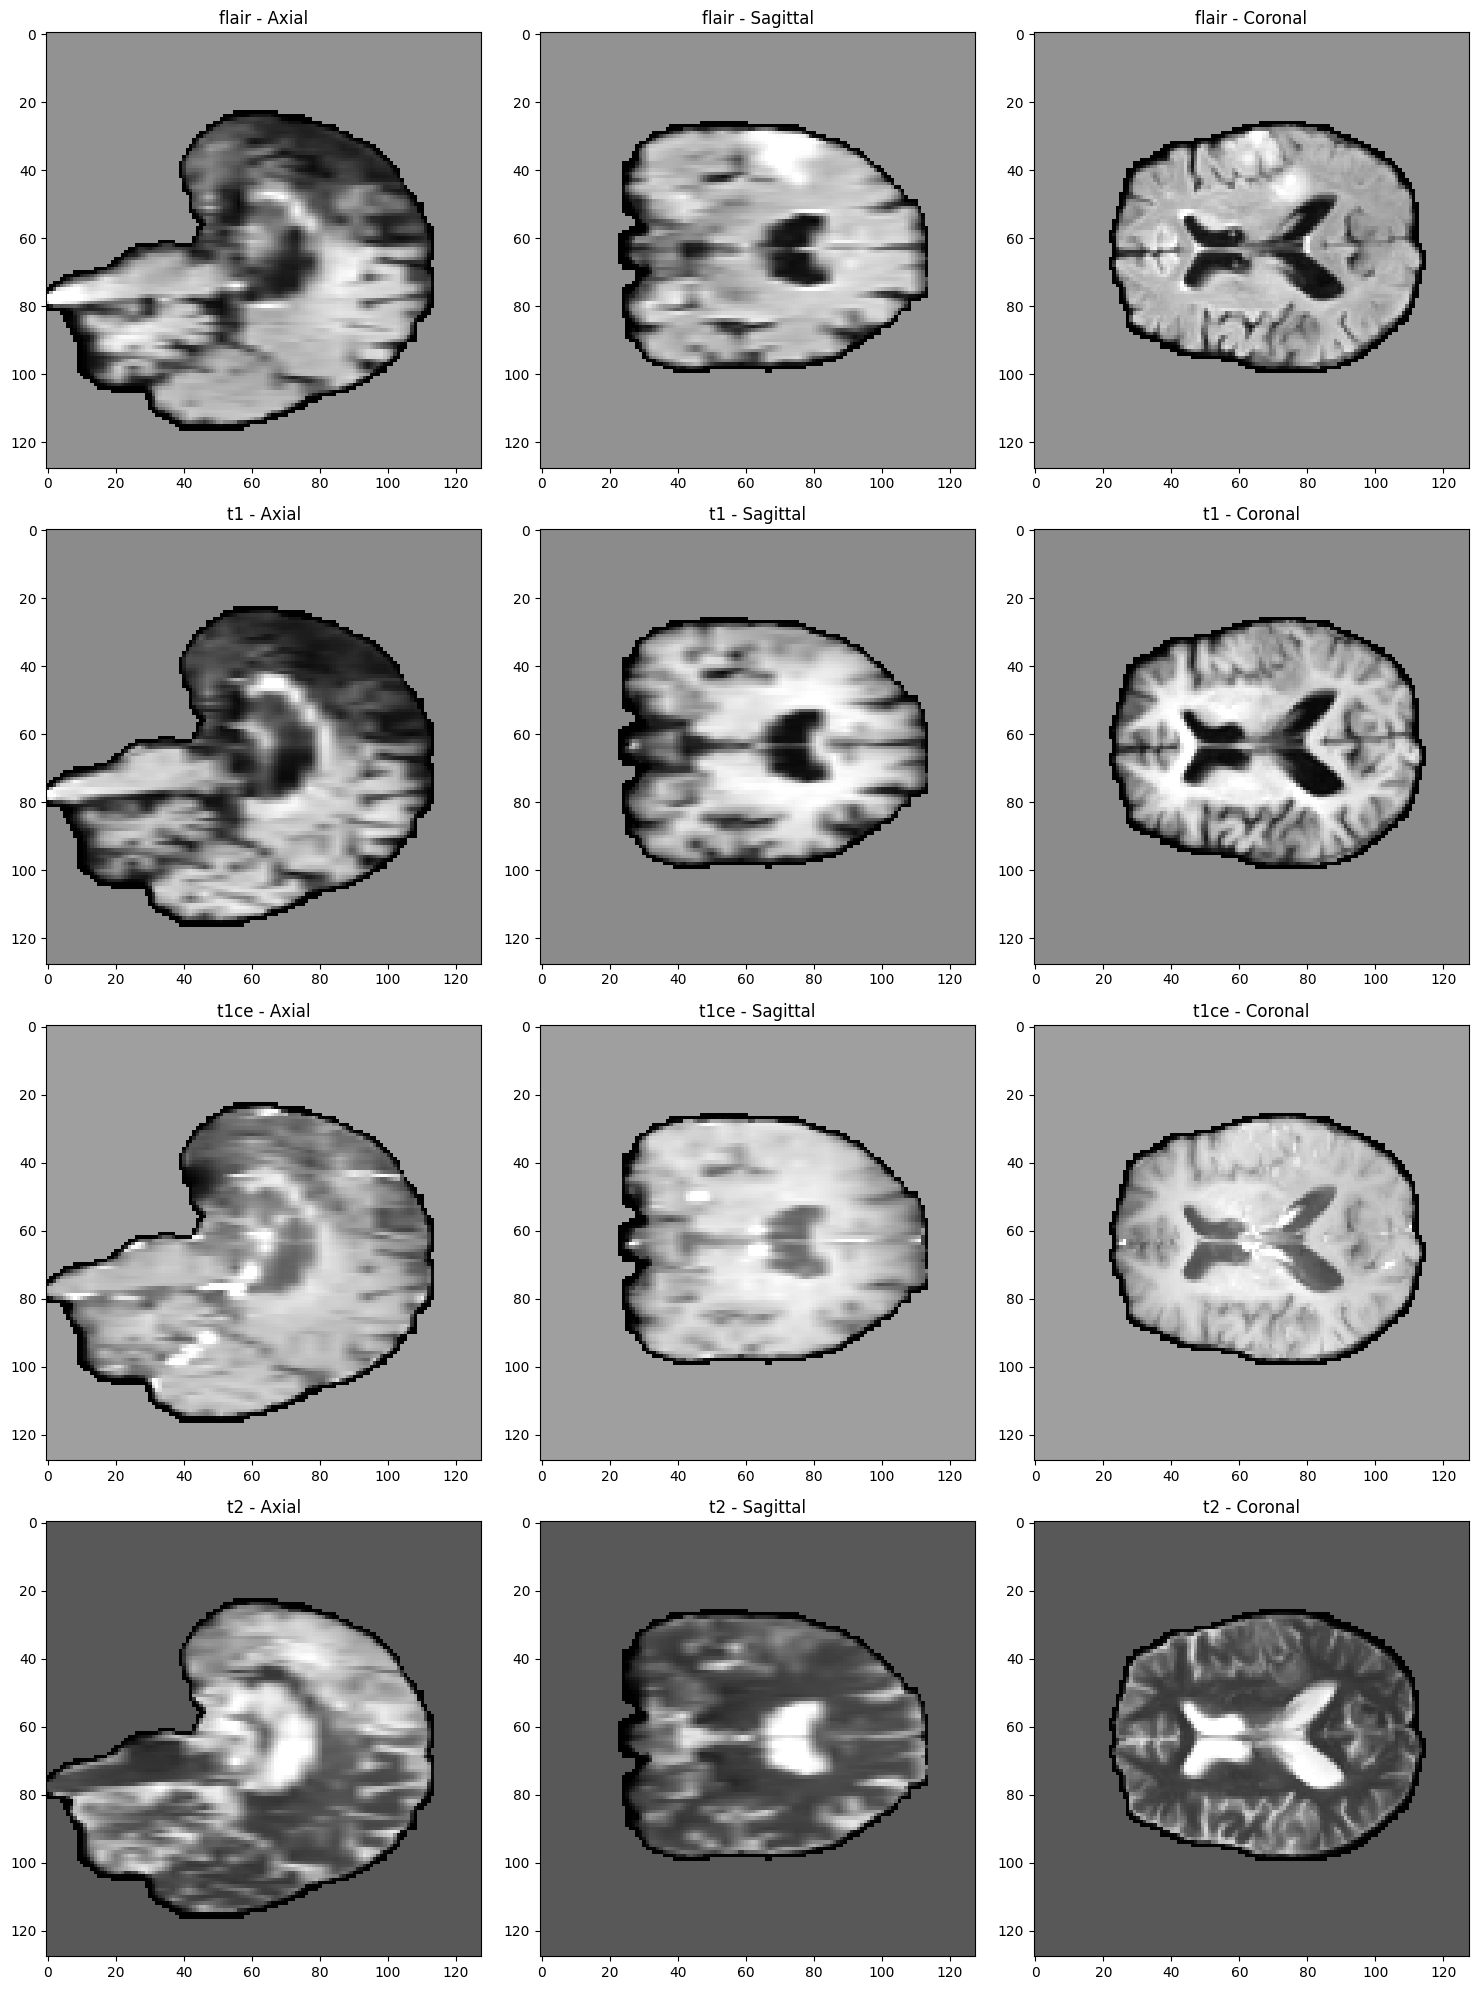

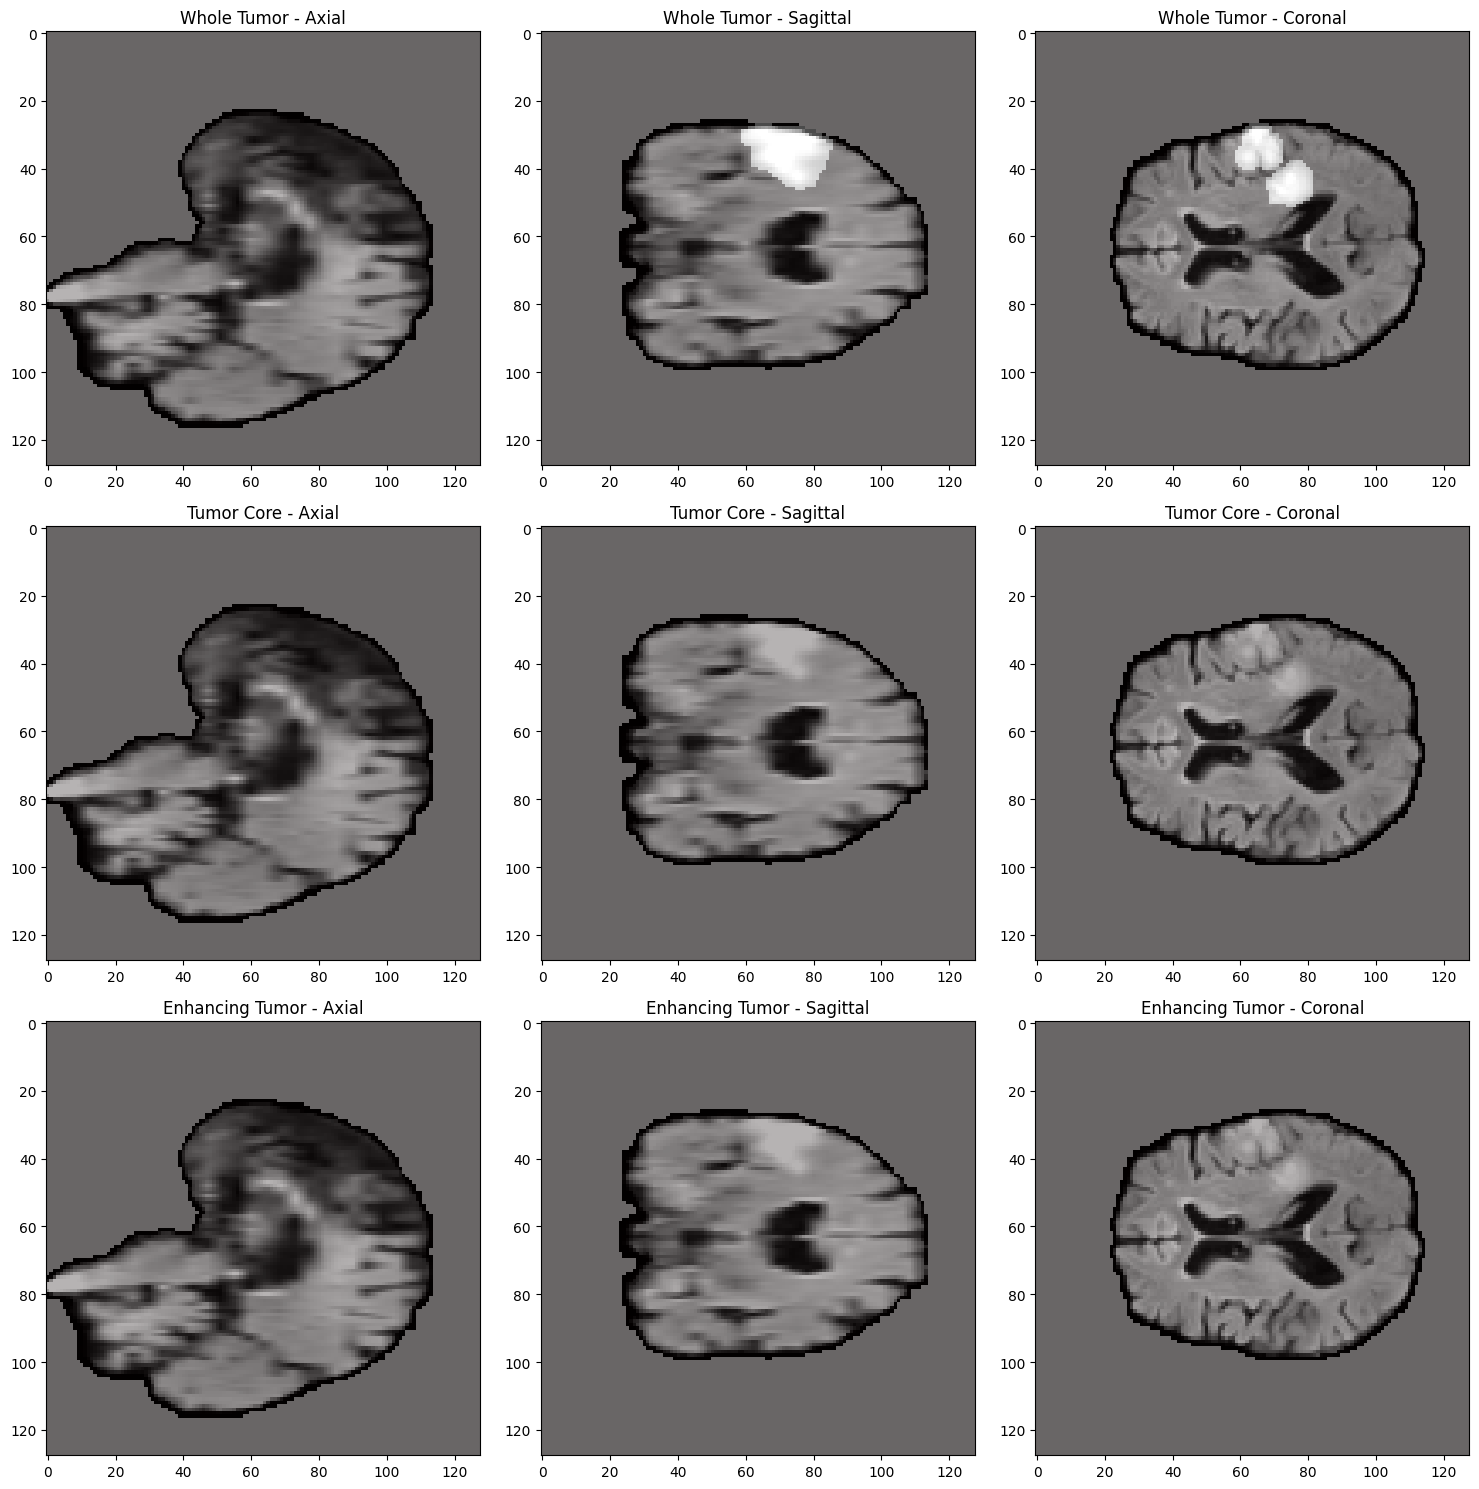

In [6]:
# Visualize a sample
sample_file = glob.glob(os.path.join(OUTPUT_PATH, "*.h5"))[0]
visualize_sample(sample_file)

In [ ]:
# Get dataset statistics
get_dataset_stats()

## Create TorchIO Dataset Classes

In [8]:
class BraTSDataset(Dataset):
    """Dataset class for loading preprocessed BraTS data"""
    def __init__(self, split='train', transform=None):
        # Load split file
        self.df = pd.read_csv(os.path.join(OUTPUT_PATH, f"{split}.csv"))
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        file_path = self.df.iloc[idx]['file_path']
        with h5py.File(file_path, 'r') as f:
            input_volume = f['input'][()]
            seg_volume = f['seg'][()]
        
        # Convert to PyTorch tensors
        input_tensor = torch.from_numpy(input_volume)
        seg_tensor = torch.from_numpy(seg_volume).permute(3, 0, 1, 2) # [C, D, H, W]
        
        # Create a TorchIO Subject
        subject = tio.Subject(
            input=tio.ScalarImage(tensor=input_tensor),
            seg=tio.LabelMap(tensor=seg_tensor),
            patient_id=self.df.iloc[idx]['patient_id']
        )
        
        if self.transform:
            subject = self.transform(subject)
        
        # Convert back to dictionary if needed
        sample = {
            'input': subject['input'].data,
            'seg': subject['seg'].data,
            'patient_id': subject['patient_id']
        }
    
        return sample

def get_transforms(split):
    """Get appropriate transforms based on split"""
    if split == 'train':
        return tio.Compose([
            # Augmentations for training
            tio.Lambda(lambda x: x),  # Identity transform as placeholder
            tio.RandomFlip(axes=(0, 1, 2), p=0.5),
            tio.RandomAffine(scales=(0.9, 1.1), degrees=10, p=0.5),
            tio.RandomGamma(p=0.3),
            tio.RandomNoise(p=0.2),
            tio.RandomMotion(p=0.2),
            tio.RandomBiasField(p=0.3)
        ])
    else:
        # No augmentation for validation/test
        return tio.Lambda(lambda x: x)

In [9]:
from torchio.data import SubjectsLoader 

# Create sample dataloaders using SubjectsLoader instead of DataLoader
train_dataset = BraTSDataset(split='train', transform=get_transforms('train'))
val_dataset = BraTSDataset(split='val', transform=get_transforms('val'))
test_dataset = BraTSDataset(split='test', transform=get_transforms('test'))

train_loader = SubjectsLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = SubjectsLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = SubjectsLoader(test_dataset, batch_size=2, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Test data loader
batch = next(iter(train_loader))
print(f"Input shape: {batch['input'].shape}")
print(f"Segmentation shape: {batch['seg'].shape}")

Train samples: 625
Validation samples: 133
Test samples: 135


/Users/Viku/GitHub/Brain_Tumour_Segmentation_V2/.venv/lib/python3.10/site-packages/torchio/data/image.py:248: UserWarning: Using TorchIO images without a torchio.SubjectsLoader in PyTorch >= 2.3 might have unexpected consequences, e.g., the collated batches will be instances of torchio.Subject with 5D images. Replace your PyTorch DataLoader with a torchio.SubjectsLoader so that the collated batch becomes a dictionary, as expected. See https://github.com/fepegar/torchio/issues/1179 for more context about this issue.
  warnings.warn(message, stacklevel=1)


Input shape: torch.Size([2, 4, 128, 128, 128])
Segmentation shape: torch.Size([2, 3, 128, 128, 128])


## Training Loop

In [10]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

In [17]:
# Create model
model = SWINNVNet(**CONFIG['model_params']).to(device)

# Loss function
criterion = CombinedLoss(dice_weight=0.5, bce_weight=0.3, focal_weight=0.2).to(device)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=CONFIG['learning_rate'] / 100
)

# Initialize mixed precision scaler if enabled
scaler = torch.amp.GradScaler() if CONFIG['mixed_precision'] else None

def dice_coefficient(y_pred, y_true, smooth=1e-6):
    """Calculate Dice coefficient for evaluation"""
    y_pred = torch.sigmoid(y_pred)  # Apply sigmoid to predictions
    
    # Flatten the tensors
    y_pred_flat = y_pred.view(-1)
    y_true_flat = y_true.view(-1)
    
    intersection = torch.sum(y_pred_flat * y_true_flat)
    union = torch.sum(y_pred_flat) + torch.sum(y_true_flat)
    
    return (2. * intersection + smooth) / (union + smooth)

def calculate_metrics(outputs, targets):
    """Calculate metrics for each class"""
    batch_size = outputs.size(0)
    num_classes = outputs.size(1)
    dice_scores = torch.zeros(num_classes)
    
    for i in range(num_classes):
        dice_scores[i] = dice_coefficient(outputs[:, i], targets[:, i])
    
    # Calculate mean dice across classes
    mean_dice = torch.mean(dice_scores)
    
    # Create a dictionary of metrics
    metrics = {
        'dice_whole_tumor': dice_scores[0].item(),
        'dice_tumor_core': dice_scores[1].item(),
        'dice_enhancing_tumor': dice_scores[2].item(),
        'mean_dice': mean_dice.item()
    }
    
    return metrics

In [18]:
from torchsummary import summary
summary(model, input_size=(4, 128, 128, 128), device='cpu')


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1    [-1, 16, 128, 128, 128]           1,744
         GroupNorm-2    [-1, 16, 128, 128, 128]              32
             PReLU-3    [-1, 16, 128, 128, 128]               1
        InputBlock-4    [-1, 16, 128, 128, 128]               0
            Conv3d-5       [-1, 32, 64, 64, 64]           4,128
            Conv3d-6       [-1, 32, 64, 64, 64]          27,680
         GroupNorm-7       [-1, 32, 64, 64, 64]              64
             PReLU-8       [-1, 32, 64, 64, 64]               1
            Conv3d-9       [-1, 32, 64, 64, 64]          27,680
        GroupNorm-10       [-1, 32, 64, 64, 64]              64
            PReLU-11       [-1, 32, 64, 64, 64]               1
    VNetDownBlock-12       [-1, 32, 64, 64, 64]               0
           Conv3d-13       [-1, 64, 32, 32, 32]          16,448
           Conv3d-14       [-1, 64, 32,

In [19]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """Train the model for one epoch"""
    model.train()
    epoch_loss = 0
    dice_scores = torch.zeros(3).to(device)  # Dice scores for 3 classes
    num_batches = len(dataloader)
    
    with tqdm(dataloader, desc="Training", leave=False) as pbar:
        for batch in pbar:
            inputs = batch['input'].to(device)
            targets = batch['seg'].to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Mixed precision training if enabled
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                
                # Backward and optimize with gradient scaling
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                # Standard training
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
            
            # Compute metrics
            with torch.no_grad():
                batch_dice = calculate_metrics(outputs, targets)
                dice_scores += batch_dice
            
            # Update statistics
            epoch_loss += loss.item()
            pbar.set_postfix({'loss': loss.item(), 'dice': batch_dice.mean().item()})
    
    # Calculate average metrics
    avg_loss = epoch_loss / num_batches
    avg_dice = dice_scores / num_batches
    
    return avg_loss, avg_dice


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    val_loss = 0
    dice_scores = torch.zeros(3).to(device)  # Dice scores for 3 classes
    num_batches = len(dataloader)
    
    with torch.no_grad():
        with tqdm(dataloader, desc="Validation", leave=False) as pbar:
            for batch in pbar:
                inputs = batch['input'].to(device)
                targets = batch['seg'].to(device)
                
                # Forward pass
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                # Compute metrics
                batch_dice = calculate_metrics(outputs, targets)
                dice_scores += batch_dice
                
                # Update statistics
                val_loss += loss.item()
                pbar.set_postfix({'loss': loss.item(), 'dice': batch_dice.mean().item()})
    
    # Calculate average metrics
    avg_loss = val_loss / num_batches
    avg_dice = dice_scores / num_batches
    
    return avg_loss, avg_dice

In [20]:
def calculate_metrics(outputs, targets):
    """Calculate metrics for each class"""
    batch_size = outputs.size(0)
    num_classes = outputs.size(1)
    dice_scores = torch.zeros(num_classes).to(outputs.device)
    
    for i in range(num_classes):
        dice_scores[i] = dice_coefficient(outputs[:, i], targets[:, i])
    
    return dice_scores

In [21]:
def plot_training_curves(results):
    """Plot training and validation curves"""
    plt.figure(figsize=(15, 10))
    
    # Plot loss
    plt.subplot(2, 2, 1)
    plt.plot(results['epoch'], results['train_loss'], label='Train Loss')
    plt.plot(results['epoch'], results['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    # Plot Dice score
    plt.subplot(2, 2, 2)
    plt.plot(results['epoch'], results['train_dice'], label='Train Dice')
    plt.plot(results['epoch'], results['val_dice'], label='Val Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Training and Validation Dice Score')
    plt.legend()
    
    # Plot class-wise Dice scores
    plt.subplot(2, 2, 3)
    plt.plot(results['epoch'], results['wt_dice'], label='Whole Tumor')
    plt.plot(results['epoch'], results['tc_dice'], label='Tumor Core')
    plt.plot(results['epoch'], results['et_dice'], label='Enhancing Tumor')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Class-wise Validation Dice Scores')
    plt.legend()
    
    # Plot learning rate
    plt.subplot(2, 2, 4)
    plt.plot(results['epoch'], results['learning_rate'])
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.yscale('log')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_path'], 'training_curves.png'))
    plt.show()

In [22]:
def inference_on_test_set(model, test_loader, device):
    """Run inference on the test set and save results"""
    model.eval()
    test_results = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            inputs = batch['input'].to(device)
            targets = batch['seg'].to(device)
            patient_ids = batch['patient_id']
            
            # Forward pass
            outputs = model(inputs)
            
            # Apply sigmoid to get probabilities
            probs = torch.sigmoid(outputs)
            
            # Calculate metrics
            batch_dice = calculate_metrics(outputs, targets)
            
            # Convert to binary predictions using 0.5 threshold
            preds = (probs > 0.5).float()
            
            # Store results for each patient
            for i in range(len(patient_ids)):
                patient_dice = [batch_dice[c][i].item() for c in range(3)]
                test_results.append({
                    'patient_id': patient_ids[i],
                    'wt_dice': patient_dice[0],
                    'tc_dice': patient_dice[1],
                    'et_dice': patient_dice[2],
                    'mean_dice': sum(patient_dice) / 3
                })
                
                # Save prediction for visualization
                # Here, you can save the prediction volumes for later analysis
                # This is optional and depends on your needs
    
    # Create a DataFrame with test results
    results_df = pd.DataFrame(test_results)
    results_df.to_csv(os.path.join(CONFIG['output_path'], 'test_results.csv'), index=False)
    
    # Calculate overall metrics
    print("\nTest Results:")
    print(f"Mean Dice Score: {results_df['mean_dice'].mean():.4f}")
    print(f"Whole Tumor Dice: {results_df['wt_dice'].mean():.4f}")
    print(f"Tumor Core Dice: {results_df['tc_dice'].mean():.4f}")
    print(f"Enhancing Tumor Dice: {results_df['et_dice'].mean():.4f}")
    
    return results_df


In [23]:
def visualize_test_case(model, test_loader, device, case_index=0):
    """Visualize a test case prediction compared to ground truth"""
    model.eval()
    
    # Get a test case
    dataset = test_loader.dataset
    sample = dataset[case_index]
    
    input_volume = sample['input'].unsqueeze(0).to(device)  # Add batch dimension
    gt_seg = sample['seg']
    patient_id = sample['patient_id']
    
    # Run inference
    with torch.no_grad():
        output = model(input_volume)
        pred_probs = torch.sigmoid(output).squeeze(0).cpu()  # Remove batch dimension
        pred_seg = (pred_probs > 0.5).float()
    
    # Get middle slice for visualization
    z_mid = input_volume.shape[2] // 2
    
    # Plot ground truth vs prediction
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    segment_names = ['Whole Tumor', 'Tumor Core', 'Enhancing Tumor']
    
    for i, name in enumerate(segment_names):
        # Ground truth
        axes[i, 0].imshow(input_volume[0, 0, z_mid].cpu(), cmap='gray')
        axes[i, 0].imshow(gt_seg[i, z_mid].cpu(), cmap='hot', alpha=0.3)
        axes[i, 0].set_title(f"{name} - Ground Truth")
        
        # Prediction probabilities
        axes[i, 1].imshow(input_volume[0, 0, z_mid].cpu(), cmap='gray')
        axes[i, 1].imshow(pred_probs[i, z_mid], cmap='hot', alpha=0.3)
        axes[i, 1].set_title(f"{name} - Prediction Probabilities")
        
        # Binary prediction
        axes[i, 2].imshow(input_volume[0, 0, z_mid].cpu(), cmap='gray')
        axes[i, 2].imshow(pred_seg[i, z_mid], cmap='hot', alpha=0.3)
        axes[i, 2].set_title(f"{name} - Binary Prediction")
    
    plt.suptitle(f"Patient: {patient_id}")
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_path'], f'prediction_{patient_id}.png'))
    plt.show()

In [24]:
def train_model():
    """Main training function"""
    # Create a results dataframe for tracking training
    columns = ['epoch', 'train_loss', 'val_loss', 'train_dice', 'val_dice',
               'wt_dice', 'tc_dice', 'et_dice', 'learning_rate', 'time']
    results = pd.DataFrame(columns=columns)
    
    # Training configuration
    best_val_dice = 0
    no_improvement_count = 0
    start_time = time.time()
    
    # Training loop
    for epoch in range(CONFIG['num_epochs']):
        epoch_start = time.time()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Train for one epoch
        train_loss, train_dice = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )
        
        # Validate
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        
        # Calculate elapsed time
        epoch_time = time.time() - epoch_start
        total_time = time.time() - start_time
        
        # Print metrics
        print(f"Epoch {epoch+1}/{CONFIG['num_epochs']} - {epoch_time:.2f}s")
        print(f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice.mean().item():.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice.mean().item():.4f}")
        print(f"Class Dice - WT: {val_dice[0]:.4f}, TC: {val_dice[1]:.4f}, ET: {val_dice[2]:.4f}")
        print(f"Learning Rate: {current_lr:.6f}")
        
        # Save results
        results = results.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_dice': train_dice.mean().item(),
            'val_dice': val_dice.mean().item(),
            'wt_dice': val_dice[0].item(),
            'tc_dice': val_dice[1].item(),
            'et_dice': val_dice[2].item(),
            'learning_rate': current_lr,
            'time': total_time
        }, ignore_index=True)
        
        # Save results to CSV
        results.to_csv(os.path.join(CONFIG['output_path'], 'training_results.csv'), index=False)
        
        # Check for improvement
        current_val_dice = val_dice.mean().item()
        is_best = current_val_dice > best_val_dice
        
        # Save checkpoint if needed
        if (epoch + 1) % CONFIG['checkpoint_frequency'] == 0 or is_best:
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_dice': train_dice.mean().item(),
                'val_dice': current_val_dice,
                'class_dice': val_dice.tolist()
            }
            
            # Save regular checkpoint
            if (epoch + 1) % CONFIG['checkpoint_frequency'] == 0:
                torch.save(
                    checkpoint,
                    os.path.join(CONFIG['output_path'], f'checkpoint_epoch{epoch+1}.pt')
                )
            
            # Save best model
            if is_best:
                torch.save(
                    checkpoint,
                    os.path.join(CONFIG['output_path'], 'best_model.pt')
                )
                best_val_dice = current_val_dice
                no_improvement_count = 0
                print(f"New best model saved with validation Dice: {best_val_dice:.4f}")
            else:
                no_improvement_count += 1
        
        # Early stopping
        if no_improvement_count >= CONFIG['patience']:
            print(f"No improvement for {CONFIG['patience']} epochs. Early stopping.")
            break
    
    # Save final model
    torch.save(
        {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_dice': train_dice.mean().item(),
            'val_dice': current_val_dice,
            'class_dice': val_dice.tolist()
        },
        os.path.join(CONFIG['output_path'], 'final_model.pt')
    )
    
    # Plot training curves
    plot_training_curves(results)
    
    return results, model

In [25]:
if __name__ == "__main__":
    # Set random seeds for reproducibility
    torch.manual_seed(11)
    np.random.seed(11)
    
    
    # Start training
    results, trained_model = train_model()
    
    # Load best model for evaluation
    best_model = SWINNVNet(**CONFIG['model_params']).to(device)
    best_model.load_state_dict(torch.load(
        os.path.join(CONFIG['output_path'], 'best_model.pt')
    )['model_state_dict'])
    
    # Run inference on test set
    test_results = inference_on_test_set(best_model, test_loader, device)
    
    # Visualize some test cases
    for i in range(min(5, len(test_loader.dataset))):
        visualize_test_case(best_model, test_loader, device, case_index=i)
    
    print("Training and evaluation complete!")

Training:   0%|          | 0/313 [00:00<?, ?it/s]

/Users/Viku/GitHub/Brain_Tumour_Segmentation_V2/.venv/lib/python3.10/site-packages/torchio/data/image.py:248: UserWarning: Using TorchIO images without a torchio.SubjectsLoader in PyTorch >= 2.3 might have unexpected consequences, e.g., the collated batches will be instances of torchio.Subject with 5D images. Replace your PyTorch DataLoader with a torchio.SubjectsLoader so that the collated batch becomes a dictionary, as expected. See https://github.com/fepegar/torchio/issues/1179 for more context about this issue.
  warnings.warn(message, stacklevel=1)


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.